In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_df = pd.read_csv('titanic.csv')
titanic_copy = titanic_df.copy()

In [3]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

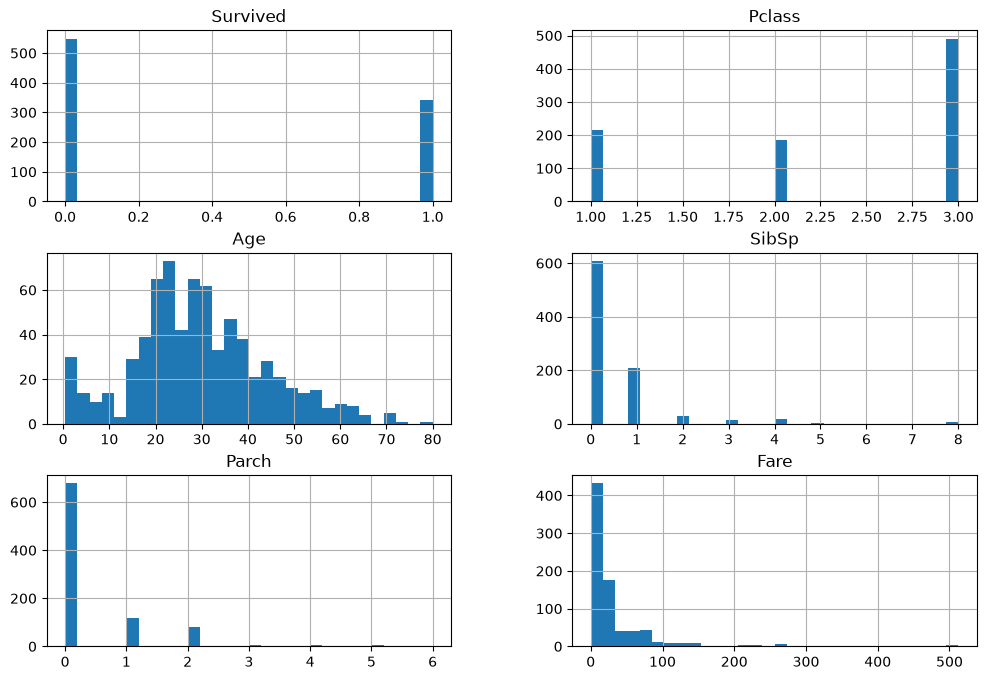

In [4]:
titanic_df = titanic_df.drop(["PassengerId"], axis = 1)
titanic_df.hist(bins = 30, figsize = (12,8))

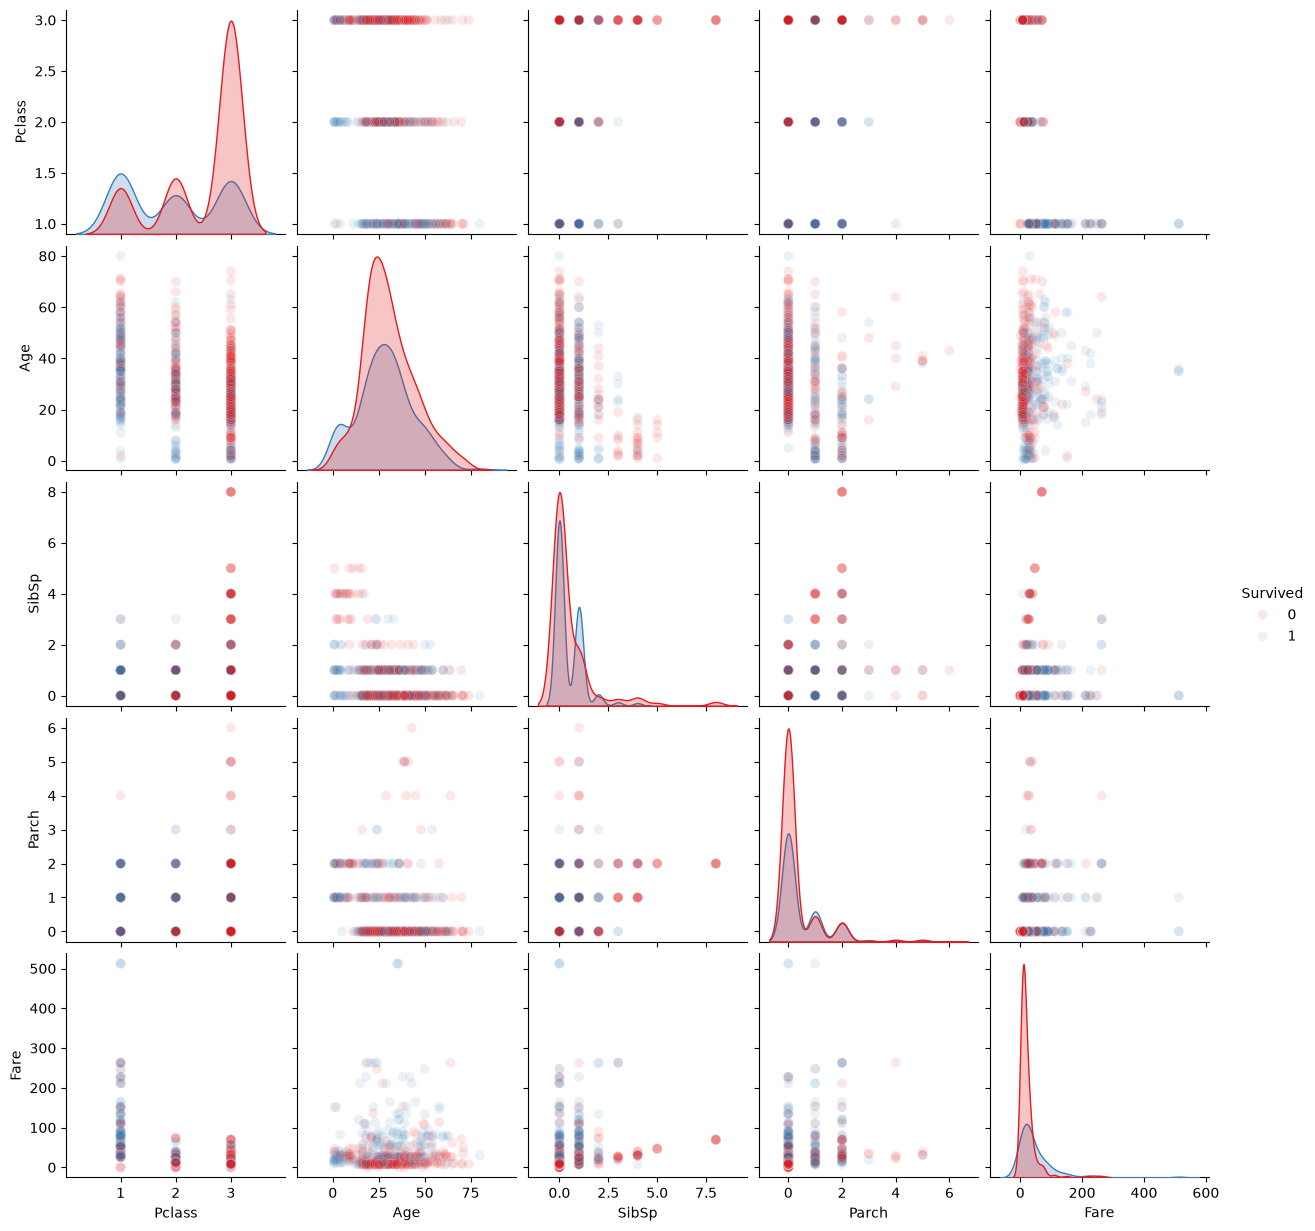

In [5]:
from pandas.plotting import scatter_matrix
basic_numeric_attributes = ["Pclass", "Age", "SibSp", "Parch","Fare","Survived"]
sns.pairplot(
    titanic_df[basic_numeric_attributes],
    hue='Survived',
    diag_kind = 'kde',
    palette='Set1',
    plot_kws={
        'alpha':0.1,
        's':50
    }
)
plt.show()

In [6]:
"""outlinery które widać z tego wykresu jak i z powyższych histogramów występują dla cech:
- Fare widać parę bardzo drogich biletów
- SibSp jest pare osób co ma bardzo dużo rodzeństwa/małżonków"""

'outlinery które widać z tego wykresu jak i z powyższych histogramów występują dla cech:\n- Fare widać parę bardzo drogich biletów\n- SibSp jest pare osób co ma bardzo dużo rodzeństwa/małżonków'

In [7]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [8]:
#dużo w większości brakuje cechy Cabin, znacząco brakuje cechy Age, i nieznacząco Fare oraz Embarked

titanic_categorial = pd.DataFrame()#przyda się później do wykresu
titanic_categorial["Survived"] = titanic_df["Survived"]#przyda się później do wykresu 
titanic_categorial["Embarked"] = titanic_df["Embarked"]#przyda się później do wykresu

from sklearn.impute import SimpleImputer

Embarked_df = titanic_df[["Embarked"]]
Embarked_imputer = SimpleImputer(strategy = "most_frequent")
Embarked_imputer.fit(Embarked_df)


Embarked_filled = Embarked_imputer.transform(Embarked_df)

titanic_df["Embarked"]= Embarked_filled[:,0]
#cecha Embarked jest uzupełniona najczęściej występującymi wartościami

In [9]:

Fare_df = titanic_df[["Fare"]]
Fare_imputer = SimpleImputer(strategy = "median")
Fare_imputer.fit(Fare_df)

Fare_filled = Fare_imputer.transform(Fare_df)

titanic_df["Fare"] = Fare_filled[:,0]
#cecha Fare jest uzupełniona medianą

In [10]:
def propabilistic_filling(df, column):
    column_distribution = df[column].value_counts(normalize=True)
    probs=column_distribution.values
    values=column_distribution.index
    missing_val = df[column].isna()
    df.loc[missing_val, column] = np.random.choice(values, size = missing_val.sum(), p=probs)
    
propabilistic_filling(titanic_df, "Age")
#cecha wiek jest uzupełniona zgodnie z rozkładem prawdopodobieństwa wieku 

In [11]:
titanic_df["Cabin"]=titanic_df["Cabin"].fillna("Unknown")
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [12]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     891 non-null    str    
 10  Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [13]:
"""na tym etapie wszystkie cechy są uzupełnione"""

'na tym etapie wszystkie cechy są uzupełnione'

In [14]:
sex_mapping = {"male":0 , "female":1}
titanic_df["Sex"] = titanic_df["Sex"].map(sex_mapping)

titanic_categorial["Sex"] = titanic_df["Sex"]#przyda się później do wykresu

In [15]:
titanic_df = titanic_df.drop(["Ticket"], axis=1)


In [16]:
titanic_df = pd.get_dummies(titanic_df, columns=["Embarked"], dtype=int)

In [17]:
def words_replace(word , words_to_replace):
    if word.strip() in words_to_replace:
        return "unusual"
    else:
        return word

In [18]:
def Cabin_first_letter(Cabin):
    if Cabin == "Unknown":
        return "Unknown"
    else:
        cabin_cleared = Cabin.strip()
        return cabin_cleared[0]
titanic_df["Cabin"] = titanic_df["Cabin"].apply(Cabin_first_letter)

titanic_categorial["Cabin"] = titanic_df["Cabin"] #przyda się później do wykresu

titanic_df["Cabin"].value_counts()
#wyciąga tylko pierwszą literę kabiny może ma to wpływ na jej ulokowanie lub zostawia unknown

Cabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [19]:
titanic_df = pd.get_dummies(titanic_df,columns=["Cabin"], dtype=int)

In [20]:
def title(name):
    splitted_name = name.split(' ')
    for word in splitted_name:
        if "." in word:
            return word
    return ""

titanic_df["Name"] = titanic_df["Name"].apply(title)
titanic_df["Name"].value_counts()
#wyciąga tytuły z imienia

Name
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Major.         2
Mlle.          2
Col.           2
Don.           1
Mme.           1
Ms.            1
Lady.          1
Sir.           1
Capt.          1
Countess.      1
Jonkheer.      1
Name: count, dtype: int64

In [21]:
def get_value_count_below_n(df, column, n):
    counts = df[column].value_counts()
    items_below = counts[counts<n]
    return items_below.index
    

titanic_df["Name"] = titanic_df["Name"].apply(words_replace, args=(get_value_count_below_n(titanic_df,"Name",3),))

titanic_categorial["Name"] = titanic_df["Name"] #przyda się później do wykresu

titanic_df = pd.get_dummies(titanic_df,columns=["Name"], dtype=int)
#dla żadkich tytułów których jest <3 tworzy kategorię unusual

In [22]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,...,Cabin_G,Cabin_T,Cabin_Unknown,Name_Dr.,Name_Master.,Name_Miss.,Name_Mr.,Name_Mrs.,Name_Rev.,Name_unusual
0,0,3,0,22.0,1,0,7.2500,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1,1,1,1,38.0,1,0,71.2833,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1,...,0,0,1,0,0,1,0,0,0,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,0,3,0,35.0,0,0,8.0500,0,0,1,...,0,0,1,0,0,0,1,0,0,0


In [23]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    int64  
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked_C     891 non-null    int64  
 8   Embarked_Q     891 non-null    int64  
 9   Embarked_S     891 non-null    int64  
 10  Cabin_A        891 non-null    int64  
 11  Cabin_B        891 non-null    int64  
 12  Cabin_C        891 non-null    int64  
 13  Cabin_D        891 non-null    int64  
 14  Cabin_E        891 non-null    int64  
 15  Cabin_F        891 non-null    int64  
 16  Cabin_G        891 non-null    int64  
 17  Cabin_T        891 non-null    int64  
 18  Cabin_Unknown  891 no

In [24]:
Pclass_Fare_mean = titanic_df.groupby("Pclass")["Fare"].mean()
titanic_df["Pclass_Fare_Ratio"] = titanic_df["Fare"] / titanic_df["Pclass"].map(Pclass_Fare_mean)
#tworzy kolumne która zawiera stosunek ceny biletu do średniej z danej klasy

In [25]:
titanic_df["Family"] = titanic_df["SibSp"] + titanic_df["Parch"]

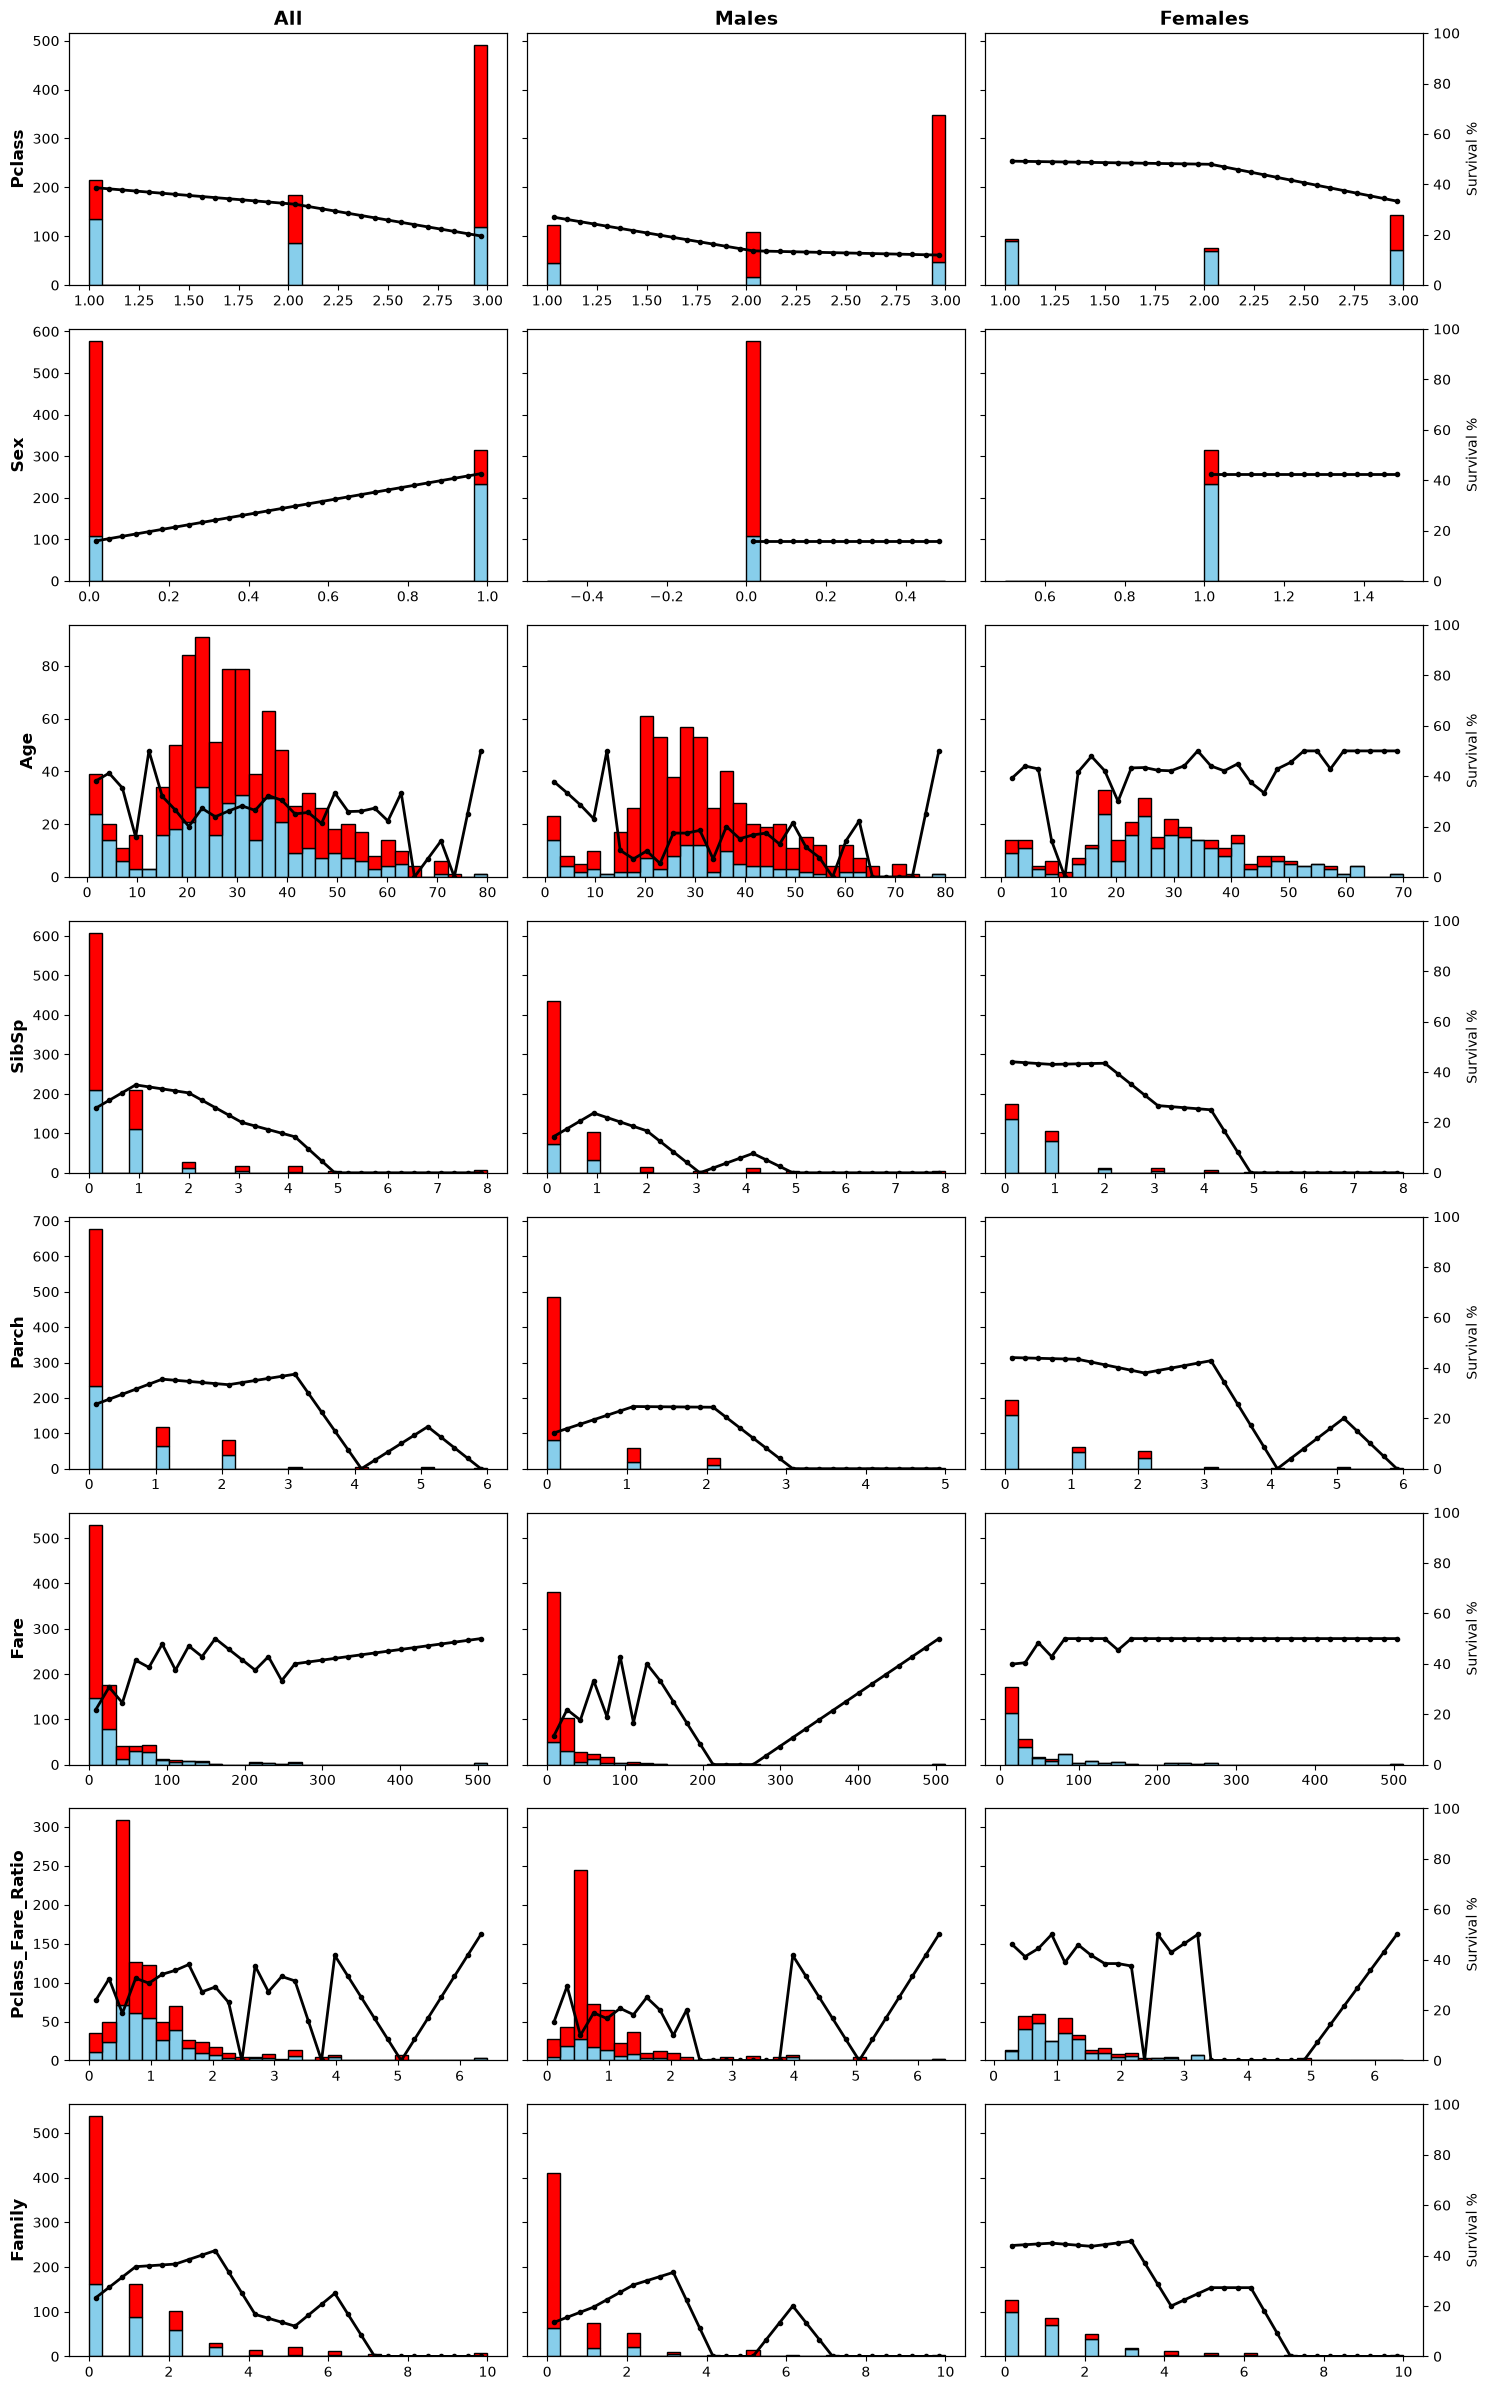

In [26]:
#ogromne znaczenie dla przeżywalności miała płeć stąd decyzja na podzielenie histogramów na cały zbiór, mężczyźni, kobiety


titanic_males, titanic_females = titanic_df[titanic_df["Sex"]==sex_mapping["male"]] , titanic_df[titanic_df["Sex"]==sex_mapping["female"]]

groups = [titanic_df, titanic_males, titanic_females]
groups_name = ["All", "Males", "Females"]

numeric_columns = titanic_df.drop(["Survived"], axis=1).select_dtypes(include=['number']).columns.tolist()

def filter_prefix(prefix, str_array):
    return [string for string in str_array if string.startswith(prefix)]

            
cabin_columns = filter_prefix("Cabin_", numeric_columns)
embarked_columns = filter_prefix("Embarked_", numeric_columns)
name_columns = filter_prefix("Name_", numeric_columns)

unwanted_col = cabin_columns + embarked_columns + name_columns

numeric_columns_filtered = [col for col in numeric_columns if col not in unwanted_col]

n_rows = len(numeric_columns_filtered)
n_cols = 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15,n_rows*3),sharey='row')

if n_rows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(numeric_columns_filtered):
    for j, (group, group_name) in enumerate(zip(groups, groups_name)):
        ax = axes[i,j]
        survived = group[group["Survived"]==1][col]
        fatalities = group[group["Survived"]==0][col]

        n, bins, patches = ax.hist(
            [survived, fatalities],
            bins = 30,
            stacked=True,
            color=['skyblue','red'],
            edgecolor='black',
            label=['survived', 'dead'] 
        )#tworzy wykres dla histogramów
            
        ax2 = ax.twinx() #tworzy oś y dla lini procentowej

        total_in_bin = n[0] + n[1] # oblicza całkowitą ilość ludzi

        survival_rate = np.divide(n[0], total_in_bin, out=np.full_like(n[0],np.nan, dtype=float), where=total_in_bin!=0)#dzieli liczbę przeżytych przez całkowitą liczbę ludzi

        interpolated_survival_rate = pd.Series(survival_rate).interpolate(method='linear')#wypełnia dziury z nieistniejącymi danymi w sposób liniowy względem brzegowych wartości
        
        bin_centers = 0.5 * (bins[:-1] + bins[1:]) #wyznacza środki dla kropek które reprezentują stosunek ocalałych od wartości cew

        ax2.plot(bin_centers, interpolated_survival_rate*100, color="black", marker='o', linewidth=2, markersize=3, label='Survival Rate (%)' if (i==0 and j==0) else "")

        ax2.set_ylim(0,100)

        if j<n_cols-1:
            ax2.yaxis.set_visible(False)
        else:
            ax2.set_ylabel('Survival %',fontsize=10)
        
        if i == 0:
            ax.set_title(group_name, fontsize=14, fontweight='bold')
        if j == 0:
            ax.set_ylabel(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


#tworzy histogramy które jednocześnie pokazują jak wyglądają statystyki dla tych co przeżyli i umarli z wyjątkiem cech zakodowanych gorącojedynkowo
#linia przedstawia prawdopodobiećstow przerzycia dla każdej z wartości z cechy, jeśli wartości cechy nieistnieją są sztucznie wypełniane liniowymmi wartościami względem najbliższych istniejących cech



In [27]:
titanic_categorial["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [28]:
titanic_categorial["Name"].value_counts()


Name
Mr.        517
Miss.      182
Mrs.       125
Master.     40
unusual     14
Dr.          7
Rev.         6
Name: count, dtype: int64

In [29]:
titanic_categorial["Cabin"].value_counts()


Cabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

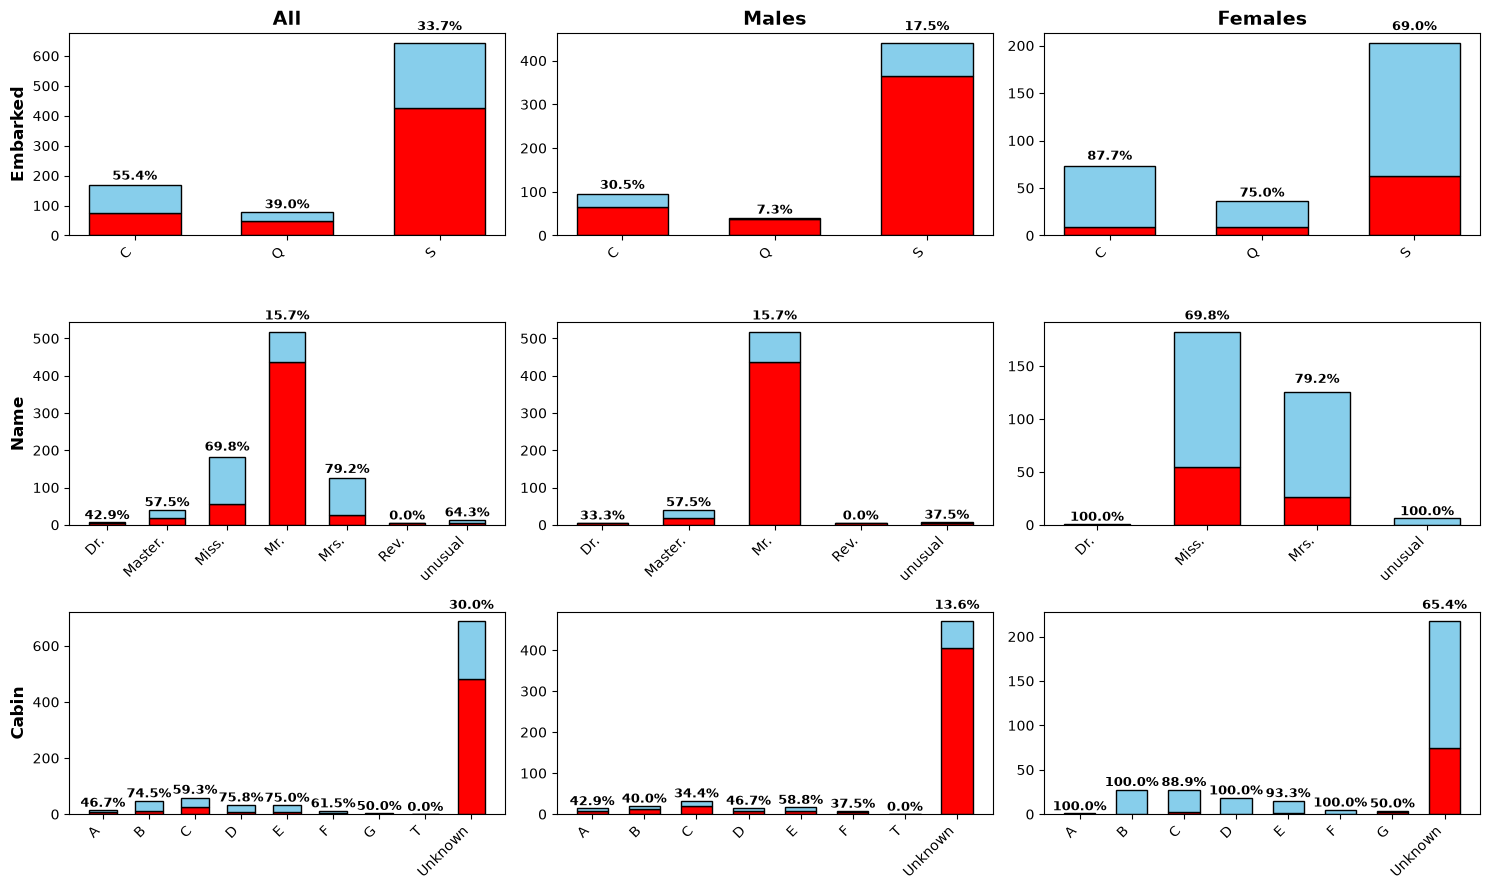

In [33]:
titanic_categorial_males, titanic_categorial_females = titanic_categorial[titanic_categorial["Sex"]==sex_mapping["male"]] , titanic_categorial[titanic_categorial["Sex"]==sex_mapping["female"]]
groups = [titanic_categorial, titanic_categorial_males, titanic_categorial_females]
groups_name = ["All","Males","Females"]
categorial_columns = ["Embarked", "Name","Cabin"]

n_rows = len(categorial_columns)
n_cols = 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15,n_rows *3), sharey=False)

if n_rows ==1:
    axes = axes.reshape(1,-1)
for i, col in enumerate(categorial_columns):
    for j, (group, group_name) in enumerate(zip(groups, groups_name)):
        ax = axes[i,j]

        survived_count = group[group["Survived"]==1][col].value_counts()
        fatalities_count = group[group["Survived"]==0][col].value_counts()

        categories = sorted(list(set(survived_count.index).union(set(fatalities_count.index))))

        survived_values = [survived_count.get(cat,0) for cat in categories]
        fatalities_values = [fatalities_count.get(cat,0) for cat in categories]

        x = np.arange(len(categories))
        width = 0.6

        ax.bar(x, fatalities_values, width, label = 'dead' if (i==0 and j==0) else"", color='red', edgecolor='black')
        ax.bar(x, survived_values, width, bottom=fatalities_values, label='survived' if (i == 0 and j == 0) else "", color='skyblue', edgecolor='black')

        for idx in range(len(categories)):
            survived_count = survived_values[idx]
            fatalities_count = fatalities_values[idx]
            total = survived_count+fatalities_count

            if total>0:
                survival_rate = (survived_count/total)*100.0
                height=total

                ax.text(
                    x[idx],
                    height * 1.05,
                    f"{survival_rate:.1f}%",
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold'
                )
        
        ax.set_xticks(x)
        ax.set_xticklabels(categories,rotation=45, ha='right')

        if i==0: 
            ax.set_title(group_name, fontsize=14, fontweight='bold')
        if j==0:
            ax.set_ylabel(col,fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



#histogramy dla cech kategorialnych odpowiednio dla wszystkich pasażerów, mężczyzn, kobiet, zawierające nad sobą szanse na przeżycie będąc w danej kategori